### Construct a forcing record for Cambridge Bay flooding simulations

**The goal:**
- Compile a continuous, 1-hourly record of atmospheric temperature, specific humidity, uv-wind, preciptiation (rain and snow), and radiation fluxes
- Compile a continuous, daily record of oceanic sst, salinity, velocity, mixed layer depth, and ocean heat flux

**The data:**
- CambridgeBayGSN_StationData.csv: 1-hourly data from the Canadian gov't weather station at the Cambridge Bay Airport (2024-01-01 through 2025-09-02)
- CBUN_complete_shore_record.csv: 1-hourly data from the Cambridge Bay Shore Station (Lufft) (2024-01-01 through 2025-11-25)
- CambridgeBay_Ocean_data.nc: monthly reanalysis data from ORA5
- CBUN_complete_CTD_record.csv: 1-hourly data from the Cambridge Bay Underwater Network (2024-01-01 through 2025-11-25)

**The process:**

*The Atmosphere*
1. Standardize the datasets (consistent units, timing, etc)
2. Split precip rate into snow and rain (use a simple atmospheric temperature threshold at freezing)
3. Compare datasets-- calculate mean offsets for any differences between the two
4. Use the airport data to infill any gaps in the Lufft record, applying the mean offset to compensate for differences.
5. Save as a standardized netcdf file. 

*The Ocean*
1. Extract sea surface temperature and sea surface salinity data from CBUN
2. Use density measurements to calculate the mixed layer depth from CBUN
3. Standardize datasets
4. Save as a standardized netcdf file.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

## The Atmosphere

In [4]:
# file = '/Users/mollyw/Desktop/ARISE-AIM/Data/preprocessed/CBUN_complete_shore_record_20240101_20251125.csv'
file = '/Users/mollyw/Desktop/ARISE-AIM/Data/preprocessed/csvs/CambridgeBayUN_SS_20240101_20260211.csv'
LUFFT = pd.read_csv(file)
LUFFT['TIME (UTC)'] = pd.to_datetime(LUFFT['Time UTC (yyyy-mm-ddThh:mm:ss.fffZ)'].values) - pd.Timedelta('30m')
LUFFT = LUFFT.drop('Time UTC (yyyy-mm-ddThh:mm:ss.fffZ)', axis=1)
LUFFT = LUFFT.set_index('TIME (UTC)')

LUFFT['y'] = np.zeros(len(LUFFT.index)) + 69.114233333
LUFFT['x'] = np.zeros(len(LUFFT.index)) + -105.058966666
LUFFT['STATION_NAME'] = 'CB_ShoreStation_Lufft'

LUFFT['TEMP (degC)'] = LUFFT['Air Temperature (C)'].astype(float)
# LUFFT['TEMP QC'] = LUFFT['Air Temperature QC Flag'].astype(int)
LUFFT = LUFFT.drop(["Air Temperature (C)"], axis=1)#, 'Air Temperature QC Flag', 'Air Temperature Count'], axis=1)

LUFFT['STATION_PRESSURE (kPa)'] = LUFFT['Air Pressure (hPa)'].astype(float)/10
# LUFFT['STATION_PRESSURE QC'] = LUFFT['Air Pressure QC Flag'].astype(int)
LUFFT = LUFFT.drop(['Air Pressure (hPa)'], axis=1)#, 'Air Pressure QC Flag', 'Air Pressure Count'], axis=1)

LUFFT['RELATIVE_HUMIDITY (%)'] = LUFFT['Relative Humidity (%)'].astype(float)
# LUFFT['RELATIVE_HUMIDITY QC'] = LUFFT['Relative Humidity QC Flag'].astype(int)
LUFFT = LUFFT.drop(['Relative Humidity (%)'], axis=1)#, 'Relative Humidity QC Flag', 'Relative Humidity Count'], axis=1)

LUFFT['DEW_POINT_TEMP (degC)'] = LUFFT['Dew Point (C)'].astype(float)
# LUFFT['DEW_POINT_TEMP QC'] = LUFFT['Dew Point QC Flag'].astype(int)
LUFFT = LUFFT.drop(['Dew Point (C)'], axis=1)#, 'Dew Point QC Flag', 'Dew Point Count'], axis=1)

LUFFT['WIND_SPEED (km/h)'] = LUFFT['Wind Speed (m/s)'].astype(float) * 3.6
# LUFFT['WIND_SPEED QC'] = LUFFT['Wind Speed QC Flag'].astype(int)
LUFFT = LUFFT.drop(['Wind Speed (m/s)'], axis=1)#, 'Wind Speed QC Flag', 'Wind Speed Count'], axis=1)


LUFFT['WIND_DIRECTION (deg)'] = LUFFT['Wind Direction (deg)'].astype(float)
# LUFFT['WIND_DIRECTION QC'] = LUFFT['Wind Direction QC Flag'].astype(int)
LUFFT = LUFFT.drop(['Wind Direction (deg)'], axis=1)#, 'Wind Direction QC Flag', 'Wind Direction Count'], axis=1)

LUFFT = LUFFT.drop(['Absolute Humidity (g/m^3)', 'Air Density (kg/m3)', 
                    'Mixing Ratio (g/kg)', 'Relative Air Pressure (hPa)', 
                    'Specific Enthalpy (kJ/kg)',], axis=1)

# fill = LUFFT.loc[slice('2024-11-01','2024-12-31')]
# # fill['TIME (UTC)'] = fill['TIME (UTC)'] + pd.Timedelta('12m')
# fill.index = fill.index + pd.Timedelta('365d')
# LUFFT = pd.concat([LUFFT.loc[slice('2024-01-01', '2025-10-31')], fill])

file = '/Users/mollyw/Desktop/ARISE-AIM/Data/preprocessed/csvs/CambridgeBayGSN_StationData_20240101_20260223.csv'
GSN = pd.read_csv(file)
GSN['TIME (UTC)'] = pd.to_datetime(GSN['TIME (UTC)'].values)
GSN = GSN.set_index('TIME (UTC)')
GSN = GSN.tz_localize('UTC')
GSN = GSN.reindex(LUFFT.index)

### In-fill Lufft data with corrected GSN data

In [5]:
def replace_missing_data(df1, df2, varname, dict):

    count = 0
    if varname == 'WIND_DIRECTION (10deg)':
        missing_times = df1['WIND_DIRECTION (deg)'][(np.isnan(df1['WIND_DIRECTION (deg)']))].index
        correction = np.nanmean(df2[varname] * 10 - df1['WIND_DIRECTION (deg)'])
        for i in range(len(df2.index)):
            if np.isnan(df1['WIND_DIRECTION (deg)'].iloc[i]):
                count += 1
                value = df2[varname].iloc[i] * 10 + correction
                df1.loc[df2.index[i], 'WIND_DIRECTION (deg)'] = value
    else:
        missing_times = df1[varname][(np.isnan(df1[varname]))].index
        correction = np.nanmean(df2[varname] - df1[varname])
        for i in range(len(df2.index)):
            if np.isnan(df1[varname].iloc[i]):
                count += 1
                value = df2[varname].iloc[i] + correction
                df1.loc[df2.index[i], varname] = value

        
    print(len(missing_times), 'times are missing for ', varname)
    print('mean differences for ', varname, ' is:', correction)
    dict[varname] = correction

    print('Dealt with ', count, ' missing values for ', varname)

    return dict, df1

2754 times are missing for  TEMP (degC)
mean differences for  TEMP (degC)  is: -0.3448446531627183
Dealt with  2754  missing values for  TEMP (degC)
2754 times are missing for  STATION_PRESSURE (kPa)
mean differences for  STATION_PRESSURE (kPa)  is: -0.3174202248574469
Dealt with  2754  missing values for  STATION_PRESSURE (kPa)
2754 times are missing for  RELATIVE_HUMIDITY (%)
mean differences for  RELATIVE_HUMIDITY (%)  is: 0.3663529459603684
Dealt with  2754  missing values for  RELATIVE_HUMIDITY (%)
2754 times are missing for  DEW_POINT_TEMP (degC)
mean differences for  DEW_POINT_TEMP (degC)  is: -0.31727385221784693
Dealt with  2754  missing values for  DEW_POINT_TEMP (degC)
2754 times are missing for  WIND_SPEED (km/h)
mean differences for  WIND_SPEED (km/h)  is: 2.9487273626854655
Dealt with  2754  missing values for  WIND_SPEED (km/h)
2754 times are missing for  WIND_DIRECTION (10deg)
mean differences for  WIND_DIRECTION (10deg)  is: -3.157063271773923
Dealt with  2754  missing

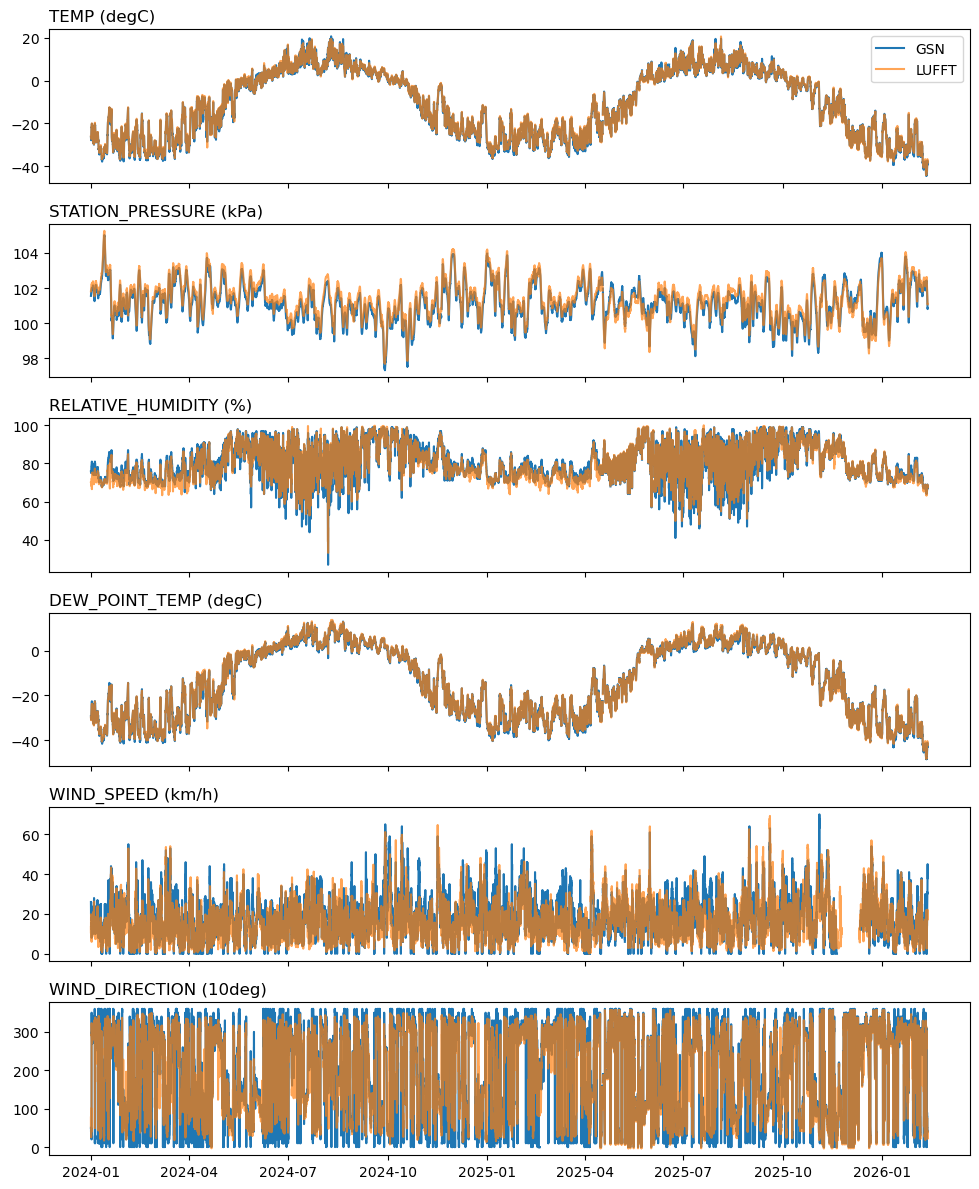

In [6]:
var_names = GSN.keys()
var_names = var_names[3:-1]
corrections = {}
for var in var_names:
    corrections, LUFFT = replace_missing_data(LUFFT, GSN, var, corrections)

fig, axes = plt.subplots(6, 1, figsize=(10, 12))

for i, varname in enumerate(var_names):
    if varname == 'WIND_DIRECTION (10deg)':
        axes[i].plot(GSN[varname] * 10)
        axes[i].plot(LUFFT['WIND_DIRECTION (deg)'], alpha = 0.7)

    else:
        axes[i].plot(GSN[varname], label = 'GSN')
        axes[i].plot(LUFFT[varname], alpha = 0.7, label = 'LUFFT')

    if i < len(var_names)-1:
        axes[i].set_xticklabels([])

    axes[i].set_title(varname, loc='left')

axes[0].legend()
plt.tight_layout()


### Separate precip rates

In [ ]:
PRECIP = GSN['PRECIP_AMOUNT (mm/hr)']
RAIN = PRECIP.where(LUFFT['TEMP (degC)'] > 0.0)
SNOW = PRECIP.where(LUFFT['TEMP (degC)'] <= 0.0)

LUFFT['RAIN_AMOUNT (mm/hr)'] = RAIN
LUFFT['SNOW_AMOUNT (mm/hr'] = SNOW

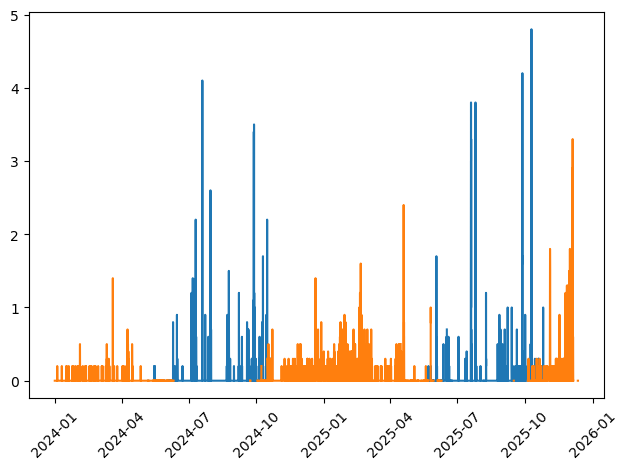

In [9]:
plt.plot(RAIN)
plt.plot(SNOW)
plt.xticks(rotation=45)
plt.tight_layout()

In [ ]:
LUFFT_nc = LUFFT.to_xarray()
LUFFT_nc['TIME (UTC)'] = LUFFT.index.values
LUFFT_nc = LUFFT_nc.rename({'TIME (UTC)': 'time', 'TEMP (degC)': 'temperature',
                 'STATION_PRESSURE (kPa)': 'pressure', 'RELATIVE_HUMIDITY (%)': 'relative_humidity',
                 'DEW_POINT_TEMP (degC)': 'dew_point_temperature', 'WIND_SPEED (km/h)': 'wind_speed',
                 'WIND_DIRECTION (deg)': 'wind_direction', 'RAIN_AMOUNT (mm/hr)': 'precip', 
                 'SNOW_AMOUNT (mm/hr': 'precip_s'})
LUFFT.to_csv('CambridgeBay_ATMOSPHERE_2024_2026.csv')

## The Ocean

In [ ]:
file = '/Users/mollyw/Desktop/ARISE-AIM/Data/preprocessed/csvs/CambridgeBayUN_CTD_20240101_20260211.csv'
CBUN = pd.read_csv(file)
CBUN['TIME (UTC)'] = pd.to_datetime(CBUN['Time UTC (yyyy-mm-ddThh:mm:ss.fffZ)'].values) - pd.Timedelta('30m')
CBUN = CBUN.drop('Time UTC (yyyy-mm-ddThh:mm:ss.fffZ)', axis=1)
CBUN = CBUN.set_index('TIME (UTC)')
CBUN[['Density (kg/m3)', 'Salinity (psu)', 'Temperature (C)']]
CBUN['Salinity (psu)'] = CBUN['Salinity (psu)'].astype(float)
CBUN['Temperature (C)'] = CBUN['Temperature (C)'].astype(float)

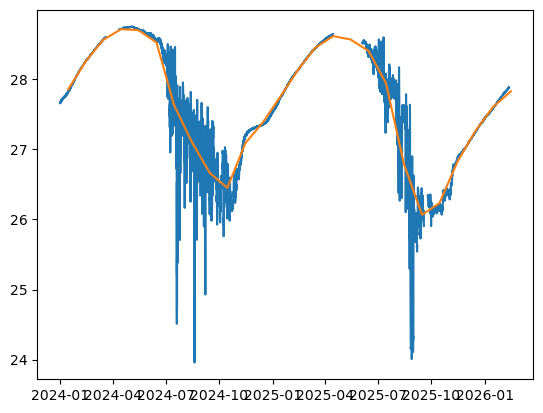

In [ ]:
sss = CBUN['Salinity (psu)'].interpolate().resample('1MS').mean()
sss.index = sss.index + pd.Timedelta('14d')
plt.plot(CBUN['Salinity (psu)'])
plt.plot(sss.index, sss)

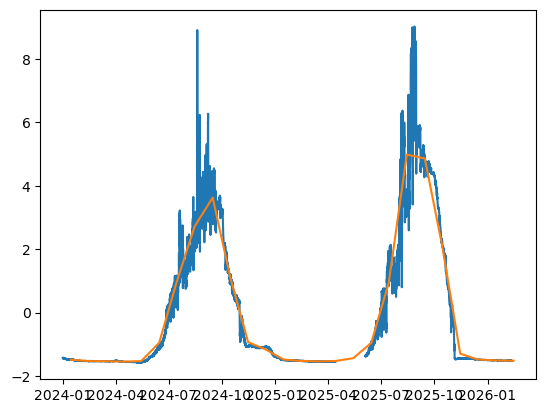

In [ ]:
sst = CBUN['Temperature (C)'].interpolate().resample('1MS').mean()
sst.index = sst.index + pd.Timedelta('14d')
plt.plot(CBUN['Temperature (C)'])
plt.plot(sst.index, sst)

In [ ]:
time = sst.index.values
CBUN_nc = xr.Dataset(data_vars = dict(sss = (['time'], sss.values),
                                      sst = (['time'], sst.values)),
                     coords = dict(time=time))
CBUN_nc = CBUN_nc.isel(time=slice(0, len(CBUN_nc.time)-1))
time = time[:-1]
ORA5_nc = xr.open_dataset('/Users/mollyw/Desktop/ARISE-AIM/Data/raw/ORA5/CambridgeBay_Ocean_data_2024_2025.nc')

In [ ]:
sst = np.reshape(sst[:-1], (len(time), 1))
sss = np.reshape(sss[:-1], (len(time), 1))

flux = np.reshape(np.concatenate([ORA5_nc.sohefldo.values.flatten(), ORA5_nc.sohefldo.values[0].flatten()]), (len(time), 1))
mixl = np.reshape(np.concatenate([ORA5_nc.somxl030.values.flatten(), ORA5_nc.somxl030.values[0].flatten()]), (len(time), 1))
vely = np.reshape(np.concatenate([ORA5_nc.vomecrty.values.flatten(), ORA5_nc.vomecrty.values[0].flatten()]), (len(time), 1))
velx = np.reshape(np.concatenate([ORA5_nc.vozocrtx.values.flatten(), ORA5_nc.vozocrtx.values[0].flatten()]), (len(time), 1))

In [ ]:
ocn_nc = xr.Dataset(data_vars = dict(sosstsst = (['time', 'loc'], sst),
                                     sosaline = (['time', 'loc'], sss),
                                     sohefldo = (['time', 'loc'], flux),
                                     somxl030 = (['time', 'loc'], mixl),
                                     vomecrty = (['time', 'loc'], vely),
                                     vozocrtx = (['time', 'loc'], velx),
                                     lat = (['loc'], ORA5_nc.lat.values),
                                     lon = (['loc'], ORA5_nc.lon.values)),
                    coords = dict(time = time))
ocn_nc.to_netcdf('CambridgeBay_OCEAN_2024_2026.nc')